# Comparing PACE and VIIRS SNPP Data
Goals:
> Plot all the data from df</p>
> Plot 2025--2024 average versus 2025 </p>
> Plot each year's monthly data </p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import matplotlib.gridspec as gridspec

In [2]:
# viirs dataset
df_v = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/VIIRS_timeseries_8D_2012-2025.csv')
df_v = df_v.iloc[592:598] # only plot data corresponding to time of PACE data
df_v = df_v.drop(columns = 'Unnamed: 0')
df_v = df_v.rename(columns = {'end_date': 'end date', 'chl-a median:': 'chl-a median'})
df_v['start date'], df_v['end date'] = pd.to_datetime(df_v['start date'].astype(str), format="%Y%m%d"), pd.to_datetime(df_v['end date'].astype(str), format="%Y%m%d")
df_v

,start date,end date,start year,start month,start day,end year,end month,end day,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR
592,2024-12-26,2024-12-31,2024,12,26,2024,12,31,0.094531,0.087583,0.091429,0.035600,1.504509,0.001267,13627,0.045991
593,2025-01-01,2025-01-08,2025,1,1,2025,1,8,0.103133,0.099157,0.096992,0.029003,1.326721,0.000841,24191,0.038662
594,2025-01-09,2025-01-16,2025,1,9,2025,1,16,0.114827,0.111413,0.103816,0.029903,1.270311,0.000894,26064,0.039550
595,2025-01-17,2025-01-24,2025,1,17,2025,1,24,0.114799,0.112225,0.110286,0.024575,1.238813,0.000604,25724,0.031569
596,2025-01-25,2025-02-01,2025,1,25,2025,2,1,0.099036,0.094886,0.095443,0.028696,1.345320,0.000823,23903,0.040408
597,2025-02-02,2025-02-09,2025,2,2,2025,2,9,0.089365,0.087231,0.083645,0.020582,1.241064,0.000424,24438,0.025317


In [3]:
# pace dataset
df_p = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/chla_PACE_timeseries_8D_PACE_OCI_L3M_CHL.csv')
df_p = df_p.drop(columns = 'Unnamed: 0')
df_p = df_p.iloc[37:43] # only plot data corresponding to time of PACE data
df_p

,start date,end date,start year,start month,start day,end year,end month,end day,chla mean,chla geometric mean,chla median,chla std,chla geometric std,chla variance,chla N,chla IQR
37,2024-12-26,2024-12-31,2024,12,26,2024,12,31,0.106695,0.100294,0.106042,0.036023,1.438609,0.001298,8922,0.048440
38,2025-01-01,2025-01-08,2025,1,1,2025,1,8,0.111912,0.107184,0.095803,0.036720,1.322212,0.001348,22959,0.035303
39,2025-01-09,2025-01-16,2025,1,9,2025,1,16,0.119854,0.116062,0.110676,0.031748,1.282954,0.001008,26529,0.042177
40,2025-01-17,2025-01-24,2025,1,17,2025,1,24,0.121037,0.117160,0.112773,0.032124,1.286728,0.001032,27042,0.038054
41,2025-01-25,2025-02-01,2025,1,25,2025,2,1,0.110018,0.104461,0.102903,0.036662,1.375846,0.001344,20202,0.050725
42,2025-02-02,2025-02-09,2025,2,2,2025,2,9,0.089796,0.086739,0.079779,0.025737,1.288578,0.000662,23002,0.027960


## Plot all data

In [4]:
start_date = df_p['start date'].values.copy()
end_date = df_p['end date'].values.copy()
# viirs
vmean = df_v['chl-a mean'].values.copy()
vgmean = df_v['chl-a geometric mean'].values.copy()
vmedian = df_v['chl-a median'].values.copy()
vstd = df_v['chl-a std'].values.copy()
vgstd = df_v['chl-a geometric std'].values.copy()
vvar = df_v['chl-a variance'].values.copy()
vN = df_v['chl-a N'].values.copy()

# pace
pmean = df_p['chla mean'].values.copy()
pgmean = df_p['chla geometric mean'].values.copy()
pmedian = df_p['chla median'].values.copy()
pstd = df_p['chla std'].values.copy()
pgstd = df_p['chla geometric std'].values.copy()
pvar = df_p['chla variance'].values.copy()
pN = df_p['chla N'].values.copy()

unit = '(mg m$^{-3}$)'
variable = 'Chlorophyll-a'

In [5]:
# test #Ns
vN-pN

array([ 4705,  1232,  -465, -1318,  3701,  1436])

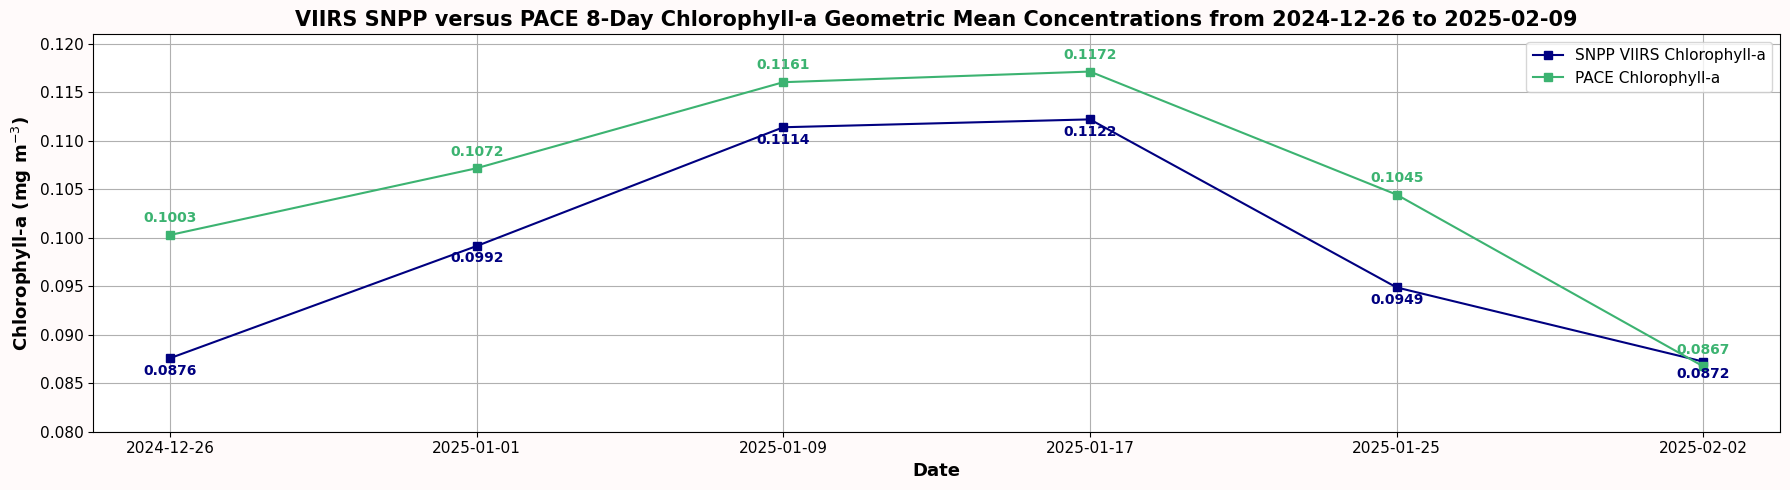

In [6]:
fig, ax = plt.subplots(figsize=(18, 5), facecolor='snow')

# plot chla_mean first
plt.plot(start_date, vgmean, linestyle = '-', color = 'navy', marker='s', label = f'SNPP VIIRS {variable}')
plt.plot(start_date, pgmean, linestyle = '-', color = 'mediumseagreen', marker='s', label = f'PACE {variable}')

plt.tick_params(axis = 'x', labelsize = 11)
plt.tick_params(axis = 'y', labelsize = 11)
plt.grid(True)
plt.ylabel(f'{variable} {unit}', fontsize = 13, fontweight = 'bold') #rotation = 0, labelpad = 130)
plt.xlabel('Date', fontsize = 13, fontweight = 'bold', rotation = 0)
plt.legend(loc='upper right', fontsize = 11)
plt.title(f'VIIRS SNPP versus PACE 8-Day {variable} Geometric Mean Concentrations from {start_date[0]} to {end_date[-1]}', fontsize = 15, fontweight = 'bold')
plt.ylim(0.08, 0.121)
# Add point labels
for xi, yi in zip(start_date, vgmean):
    ax.text(xi, yi - 0.002, f'{yi:.4f}', ha='center', va='bottom', color = 'navy', fontsize=10, fontweight = 'bold')

# Add point labels
for wi, zi in zip(start_date, pgmean):
    ax.text(wi, zi + 0.001, f'{zi:.4f}', ha='center', va='bottom',  color = 'mediumseagreen', fontsize=10, fontweight = 'bold')

plt.tight_layout()
#plt.savefig(f'/home/jovyan/Desktop/figures/PACE/VIIRS versus PACE 8-Day {variable} Concentrations', bbox_inches = 'tight', dpi = 300)

# Scatter plot

In [5]:
from scipy.stats import linregress
import matplotlib.dates as mdates

In [6]:
# viirs dataset
df_v = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/VIIRS_timeseries_8D_2012-2025.csv')
df_v = df_v.iloc[555:603]
df_v = df_v.drop(columns = 'Unnamed: 0')
df_v = df_v.rename(columns = {'end_date': 'end date', 'chl-a median:': 'chl-a median'})
df_v['start date'], df_v['end date'] = pd.to_datetime(df_v['start date'].astype(str), format="%Y%m%d"), pd.to_datetime(df_v['end date'].astype(str), format="%Y%m%d")
# pace dataset
df_p = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/chla_PACE_timeseries_8D_PACE_OCI_L3M_CHL.csv')
df_p = df_p.iloc[0:48]
df_p = df_p.drop(columns = 'Unnamed: 0')

In [7]:
# get dates (for color plotting)
colors = mdates.date2num(df_p['start date']) # convert dates to numbers (e.g., day 1, day 2, day 3, ... out of all the data I provided (meant to be used for ascending dates into future and for plotting)

pgmean_f = df_p['chla geometric mean'].values.copy()
vgmean_f = df_v['chl-a geometric mean'].values.copy()

In [8]:
# regression line
slope, intercept, r_value, p_value, std_err = linregress(pgmean_f, vgmean_f)
regression_line = slope * pgmean_f + intercept
# one to one line
min_val = min(pgmean_f.min(), vgmean_f.min())
max_val = max(pgmean_f.max(), vgmean_f.max())
one_to_one_line = np.linspace(min_val, max_val, 100)

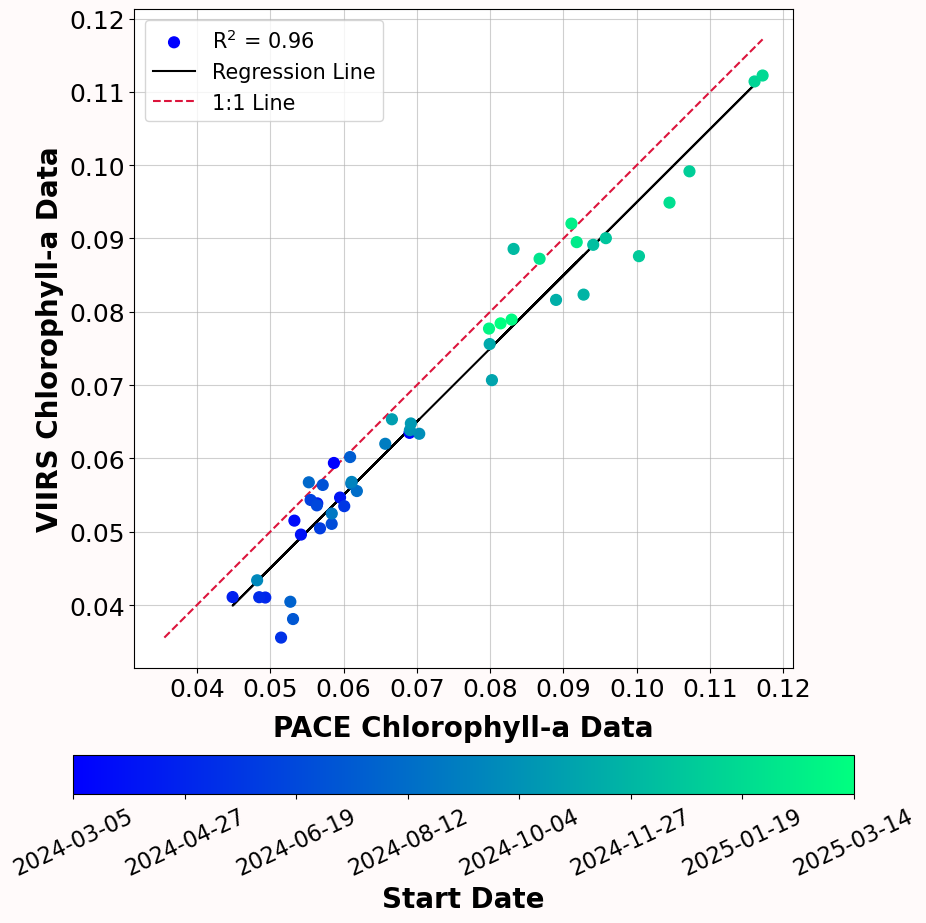

In [14]:
#fig, ax = plt.subplots(figsize=(4,4), facecolor='snow')
fig, ax = plt.subplots(figsize=(9.5,9.5), facecolor='snow')
# make the plot a square
ax.set_aspect('equal', adjustable='box')  # makes plot area square

# plot the data
data = ax.scatter(pgmean_f, vgmean_f, s=60, c = colors, cmap = 'winter', marker='o', label = f'R$^{2}$ = {r_value**2:.2f}', zorder=5)

# regression line
ax.plot(pgmean_f, regression_line, color = 'k', label = 'Regression Line')

# set the colorbar and its details
cbar = fig.colorbar(data, ax=ax, orientation='horizontal', pad=0.1, shrink=0.9)  
tick_dates = pd.date_range(df_p['start date'].min(), df_p['start date'].max(), periods=8)
cbar.set_ticks(tick_dates)
cbar.set_ticklabels(tick_dates.strftime('%Y-%m-%d'), rotation = 25, fontsize = 16)
cbar.set_label('Start Date', fontsize = 20, fontweight = 'bold')#, labelpad=15)

# one to one line
ax.plot(one_to_one_line, one_to_one_line, color = 'crimson', linestyle = '--', label = '1:1 Line')
ax.tick_params(axis='x', labelsize=18)#, rotation=-25)
ax.tick_params(axis='y',labelsize=18)

# match the numbers
ticklabels = (0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.11,0.12)
ax.set_xticks(ticklabels)
ax.set_yticks(ticklabels)
               
ax.set_ylabel('VIIRS Chlorophyll-a Data', fontsize = 20, fontweight = 'bold')
ax.set_xlabel('PACE Chlorophyll-a Data', fontsize = 20, fontweight = 'bold', labelpad=9)
ax.legend(loc = 'upper left', fontsize = 15)
ax.grid(True, alpha=0.6)
#ax.set_title('VIIRS 8-Day versus PACE 8-Day Chlorophyll-a Geometric Mean Data', fontsize = 18, fontweight = 'bold')
plt.subplots_adjust(bottom=0.1)
plt.tight_layout()
plt.savefig('/home/jovyan/Desktop/figures/changed one to one and regression.png', dpi = 300)

# Plot only chl-a data

In [7]:
df_v = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/VIIRS_timeseries_8D_2012-2025.csv')
df_v = df_v.iloc[555:620] # only plot data corresponding to time of PACE data
df_v = df_v.drop(columns = 'Unnamed: 0')
df_v = df_v.rename(columns = {'end_date': 'end date', 'chl-a median:': 'chl-a median'})
df_v['start date'], df_v['end date'] = pd.to_datetime(df_v['start date'].astype(str), format="%Y%m%d"), pd.to_datetime(df_v['end date'].astype(str), format="%Y%m%d")
df_v['start date'] = pd.to_datetime(df_v['start date'])
df_v

,start date,end date,start year,start month,start day,end year,end month,end day,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR
555,2024-03-05,2024-03-12,2024,3,5,2024,3,12,0.062576,0.059379,0.056440,0.021510,1.373570,0.000463,23692,0.024648
556,2024-03-13,2024-03-20,2024,3,13,2024,3,20,0.065890,0.063488,0.061355,0.018440,1.311613,0.000340,25174,0.023466
557,2024-03-21,2024-03-28,2024,3,21,2024,3,28,0.053322,0.051513,0.051695,0.014108,1.303171,0.000199,24757,0.018889
558,2024-03-29,2024-04-05,2024,3,29,2024,4,5,0.052033,0.049609,0.047492,0.016459,1.360606,0.000271,24623,0.021686
559,2024-04-06,2024-04-13,2024,4,6,2024,4,13,0.056960,0.054661,0.053382,0.016748,1.331754,0.000280,23483,0.020655
560,2024-04-14,2024-04-21,2024,4,14,2024,4,21,0.054759,0.053872,0.052880,0.010026,1.197901,0.000101,22092,0.011337
561,2024-04-22,2024-04-29,2024,4,22,2024,4,29,0.043482,0.041091,0.040657,0.014673,1.403863,0.000215,12627,0.018289
562,2024-04-30,2024-05-07,2024,4,30,2024,5,7,0.043349,0.041027,0.041388,0.014407,1.398698,0.000208,13622,0.020137
563,2024-05-08,2024-05-15,2024,5,8,2024,5,15,0.042987,0.041069,0.039865,0.013680,1.346872,0.000187,12469,0.014017
564,2024-05-16,2024-05-23,2024,5,16,2024,5,23,0.036998,0.035561,0.037267,0.010151,1.334903,0.000103,6630,0.012865


In [8]:
df_p = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/chla_PACE_timeseries_8D_PACE_OCI_L3M_CHL.csv')
df_p = df_p.drop(columns = 'Unnamed: 0')
df_p = df_p.iloc[0:49] # only plot data corresponding to time of PACE data
df_p['start date'] = pd.to_datetime(df_p['start date'])
df_p

,start date,end date,start year,start month,start day,end year,end month,end day,chla mean,chla geometric mean,chla median,chla std,chla geometric std,chla variance,chla N,chla IQR
0,2024-03-05,2024-03-12,2024,3,5,2024,3,12,0.060554,0.058686,0.057316,0.015550,1.282235,0.000242,14760,0.020840
1,2024-03-13,2024-03-20,2024,3,13,2024,3,20,0.071786,0.069004,0.069807,0.019872,1.330306,0.000395,21290,0.028535
2,2024-03-21,2024-03-28,2024,3,21,2024,3,28,0.054753,0.053297,0.051695,0.013200,1.257521,0.000174,23832,0.015745
3,2024-03-29,2024-04-05,2024,3,29,2024,4,5,0.057085,0.054190,0.052664,0.018550,1.381122,0.000344,21939,0.030348
4,2024-04-06,2024-04-13,2024,4,6,2024,4,13,0.062426,0.059528,0.058069,0.020088,1.355341,0.000404,22307,0.026204
5,2024-04-14,2024-04-21,2024,4,14,2024,4,21,0.057482,0.056418,0.054103,0.011673,1.208413,0.000136,20095,0.014666
6,2024-04-22,2024-04-29,2024,4,22,2024,4,29,0.045897,0.044872,0.044380,0.010719,1.230832,0.000115,15877,0.012283
7,2024-04-30,2024-05-07,2024,4,30,2024,5,7,0.052823,0.049327,0.048542,0.026568,1.410908,0.000706,7906,0.023385
8,2024-05-08,2024-05-15,2024,5,8,2024,5,15,0.050035,0.048501,0.047975,0.012719,1.282000,0.000162,5804,0.016111
9,2024-05-16,2024-05-23,2024,5,16,2024,5,23,0.054675,0.051481,0.046989,0.020031,1.404588,0.000401,3908,0.027614


2025-03-22


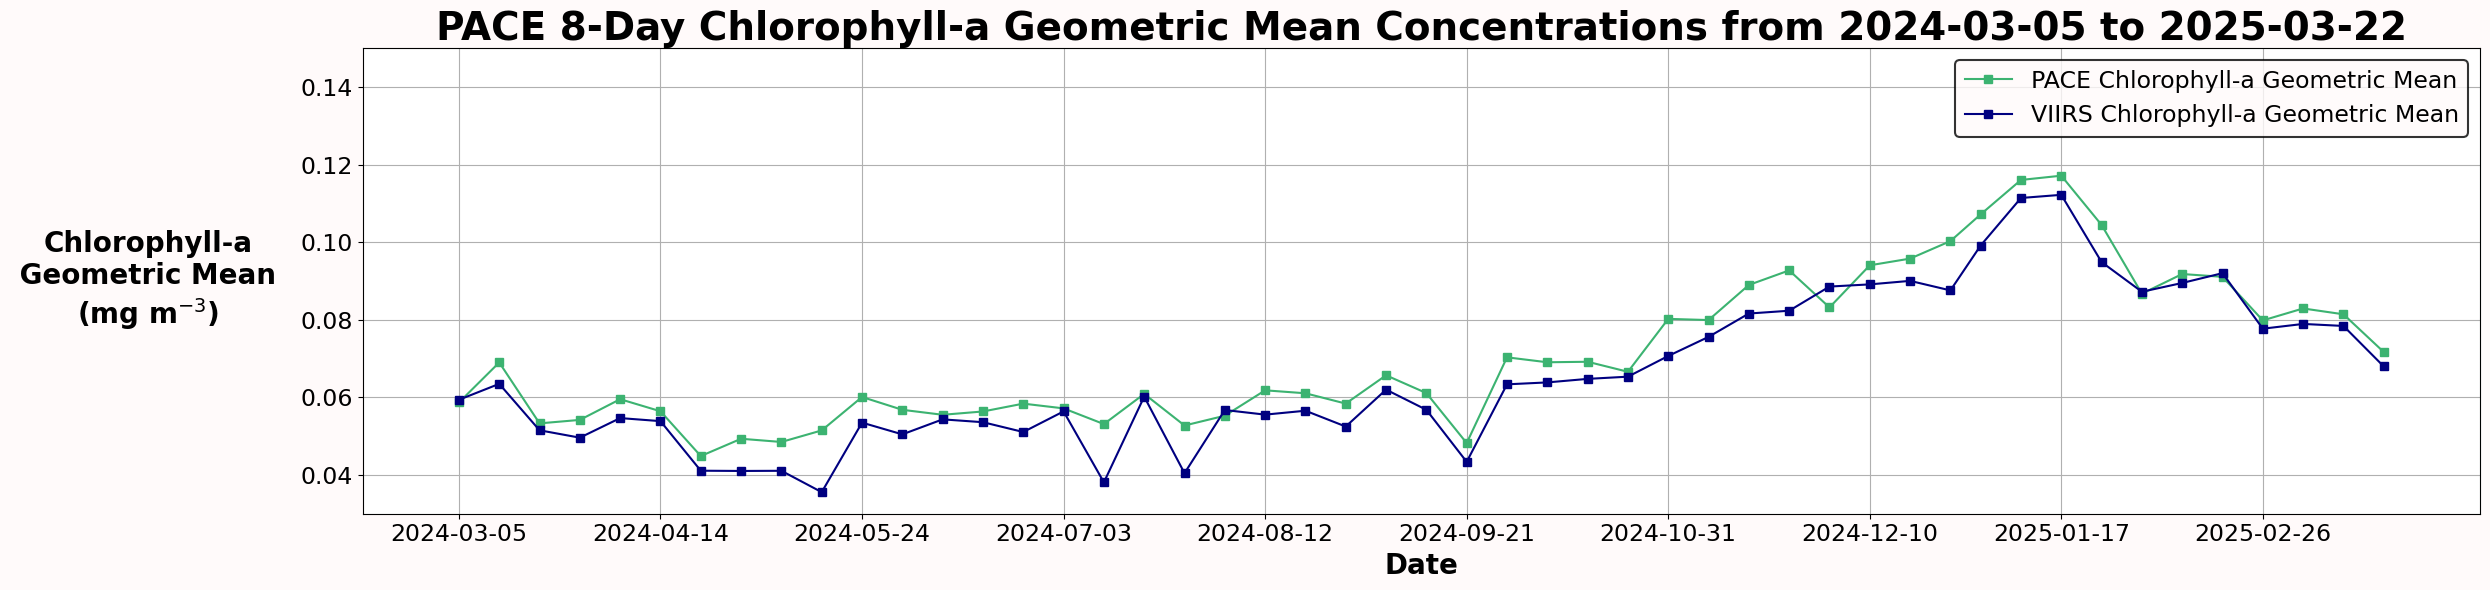

In [50]:
fig = plt.figure(figsize = (25,6), facecolor = 'snow')

# plot chlorophyll a median, mean, gmean
plt.plot(df_p['start date'], df_p['chla geometric mean'], linestyle = '-', color = 'mediumseagreen', marker='s', label = 'PACE Chlorophyll-a Geometric Mean')
#plt.plot(df_p['start date'], df_p['chla median'], linestyle = '-', color = 'firebrick', marker='s', label = 'Chlorophyll-a Median')
#plt.plot(df_p['start date'], df_p['chla mean'], linestyle = '-', color = 'dodgerblue', marker='s', label = 'Chlorophyll-a Mean')


plt.plot(df_v['start date'], df_v['chl-a geometric mean'], linestyle = '-', color = 'navy', marker='s', label = 'VIIRS Chlorophyll-a Geometric Mean')
#plt.plot(df_p['start date'], df_p['chla median'], linestyle = '-', color = 'firebrick', marker='s', label = 'Chlorophyll-a Median')
#plt.plot(df_p['start date'], df_p['chla mean'], linestyle = '-', color = 'dodgerblue', marker='s', label = 'Chlorophyll-a Mean')


plt.tick_params(axis = 'x', labelsize = 17)
plt.tick_params(axis = 'y', labelsize = 17)
plt.grid(True)
plt.xticks(df_p['start date'][::5], fontsize=17)
plt.ylabel(f'{variable}\n Geometric Mean \n{unit}', fontsize = 20, fontweight = 'bold', rotation = 0, va = 'center', labelpad = 110)
plt.xlabel('Date', fontsize = 20, fontweight = 'bold', rotation = 0)
legend = plt.legend(loc='upper right', fontsize = 17)
legend.get_frame().set_edgecolor('black')    
legend.get_frame().set_linewidth(1.5)        
legend.get_frame().set_facecolor('snow')
first_day = df_p['start date'].iloc[0].strftime('%Y-%m-%d')
last_day = df_p['start date'].iloc[-1].strftime('%Y-%m-%d')
print(last_day)
plt.title(f'PACE 8-Day Chlorophyll-a Geometric Mean Concentrations from {first_day} to {last_day}', fontsize = 28, fontweight = 'bold')
plt.ylim(0.03, 0.15)
plt.tight_layout()
plt.savefig(f'/home/jovyan/Desktop/figures/PACE/PACE 8-Day vs chl-a Concentrations', bbox_inches = 'tight', dpi = 300)

In [9]:
# for each year, get every month and make a bar plot stacking the data
df_seasonality = df.groupby(['start year','start month']).mean(numeric_only=True)
df_seasonality.reset_index(inplace=True)
#df_seasonality

In [10]:
df_seasonality = df_seasonality.drop(columns=['end year', 'end day', 'start day', 'end month'])
df_seasonality['start month'] = pd.to_datetime(df_seasonality['start month'], format = '%m').dt.strftime('%B')
#df_seasonality

In [11]:
years = df_seasonality['start year'].unique()
months = df_seasonality['start month'].unique()

dfp = df_seasonality.pivot(index='start year', columns='start month', values='chl-a geometric mean').fillna(0)

dfp = dfp[[m for m in months if m in dfp.columns]]
dfp

start month,January,February,March,April,May,June,July,August,September,October,November,December
start year,,,,,,,,,,,,
2015,0.100566,0.070430,0.064339,0.061755,0.057074,0.057228,0.057184,0.057305,0.059744,0.065322,0.087174,0.103372
2016,0.112790,0.095649,0.062370,0.048319,0.052198,0.054721,0.050362,0.044500,0.055102,0.068437,0.079601,0.107445
2017,0.104852,0.092930,0.069610,0.054140,0.049250,0.054458,0.054014,0.055529,0.064563,0.084016,0.080694,0.113251
2018,0.103327,0.088260,0.072791,0.058663,0.053945,0.050447,0.054359,0.064498,0.065213,0.073425,0.093137,0.103431
2019,0.115216,0.099040,0.067036,0.051174,0.049393,0.044075,0.054793,0.054776,0.056700,0.071218,0.077471,0.103801
2020,0.116953,0.117834,0.076704,0.057796,0.053495,0.051708,0.054258,0.053020,0.076171,0.085898,0.108101,0.125028
2021,0.133432,0.116721,0.098059,0.076213,0.067204,0.055670,0.057923,0.057218,0.070665,0.080915,0.093968,0.103546
2022,0.107825,0.089889,0.083396,0.064046,0.063897,0.058985,0.051906,0.045682,0.056328,0.069203,0.092933,0.090783
2023,0.102714,0.106517,0.073953,0.067035,0.051386,0.047146,0.053447,0.053248,0.060570,0.068452,0.081604,0.092926


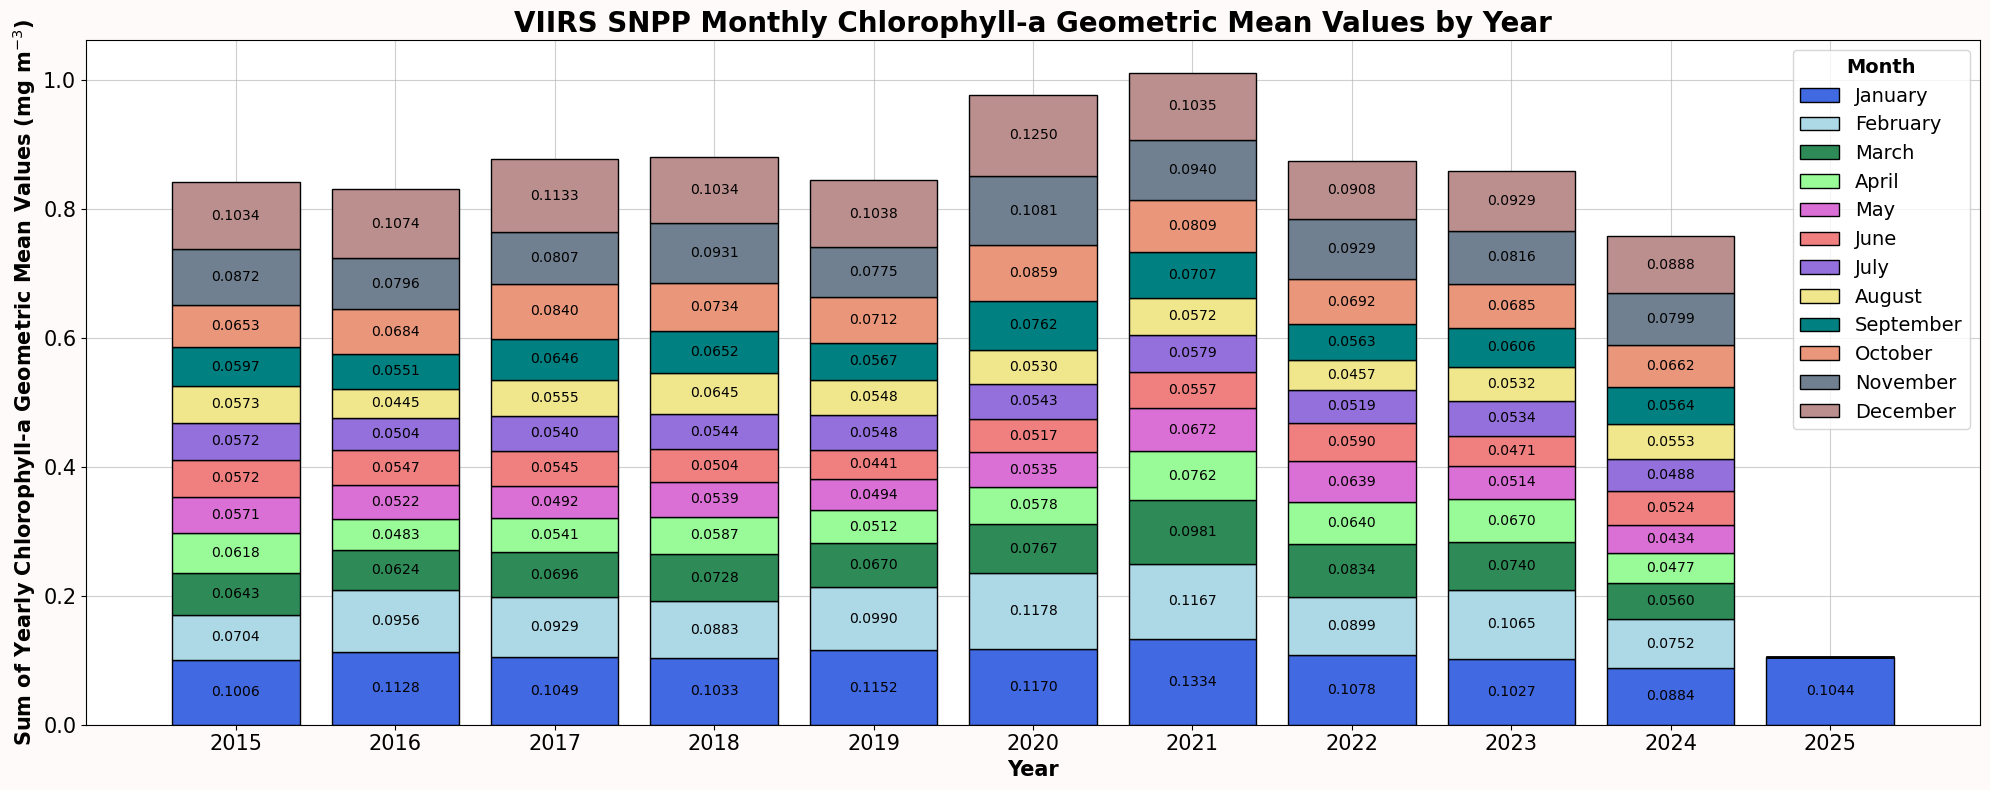

In [12]:
fig, ax = plt.subplots(figsize=(20, 8), facecolor='snow')
# set the bottom and multiply the length of the pivoted df to get an index and to stack all the bars on top of each other
bottom = [0] * len(dfp)
x = dfp.index # x is this index object

colors = {
    'January': 'royalblue',
    'February': 'lightblue',
    'March': 'seagreen',
    'April': 'palegreen',
    'May': 'orchid',
    'June': 'lightcoral',
    'July': 'mediumpurple',
    'August': 'khaki',
    'September': 'teal',
    'October': 'darksalmon',
    'November': 'slategrey',
    'December': 'rosybrown'
}


for i, month in enumerate(dfp.columns):
    heights = dfp[month].values
    bars = ax.bar(x, heights, bottom=bottom, label=month, color=colors[month], edgecolor='black', zorder = 2)
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f'{height:.4f}', ha='center', va='center', fontsize=10)
    
    bottom = [b + h for b, h in zip(bottom, heights)]

ax.set_ylabel('Sum of Yearly Chlorophyll-a Geometric Mean Values (mg m$^{-3}$)', fontsize = 15, fontweight = 'bold')
ax.set_xlabel('Year', fontsize = 15, fontweight = 'bold')
ax.set_title('VIIRS SNPP Monthly Chlorophyll-a Geometric Mean Values by Year', fontsize = 20, fontweight = 'bold')
legend = ax.legend(title='Month', loc='upper right', title_fontsize = 14, fontsize = 14)
legend.get_title().set_fontweight('bold')
plt.xticks(x, fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(True, alpha=0.6, zorder = 0)
plt.tight_layout()
plt.savefig('/home/jovyan/Desktop/figures/VIIRS SNPP 8-D/GMean month by year', bbox_inches = 'tight', dpi = 300)

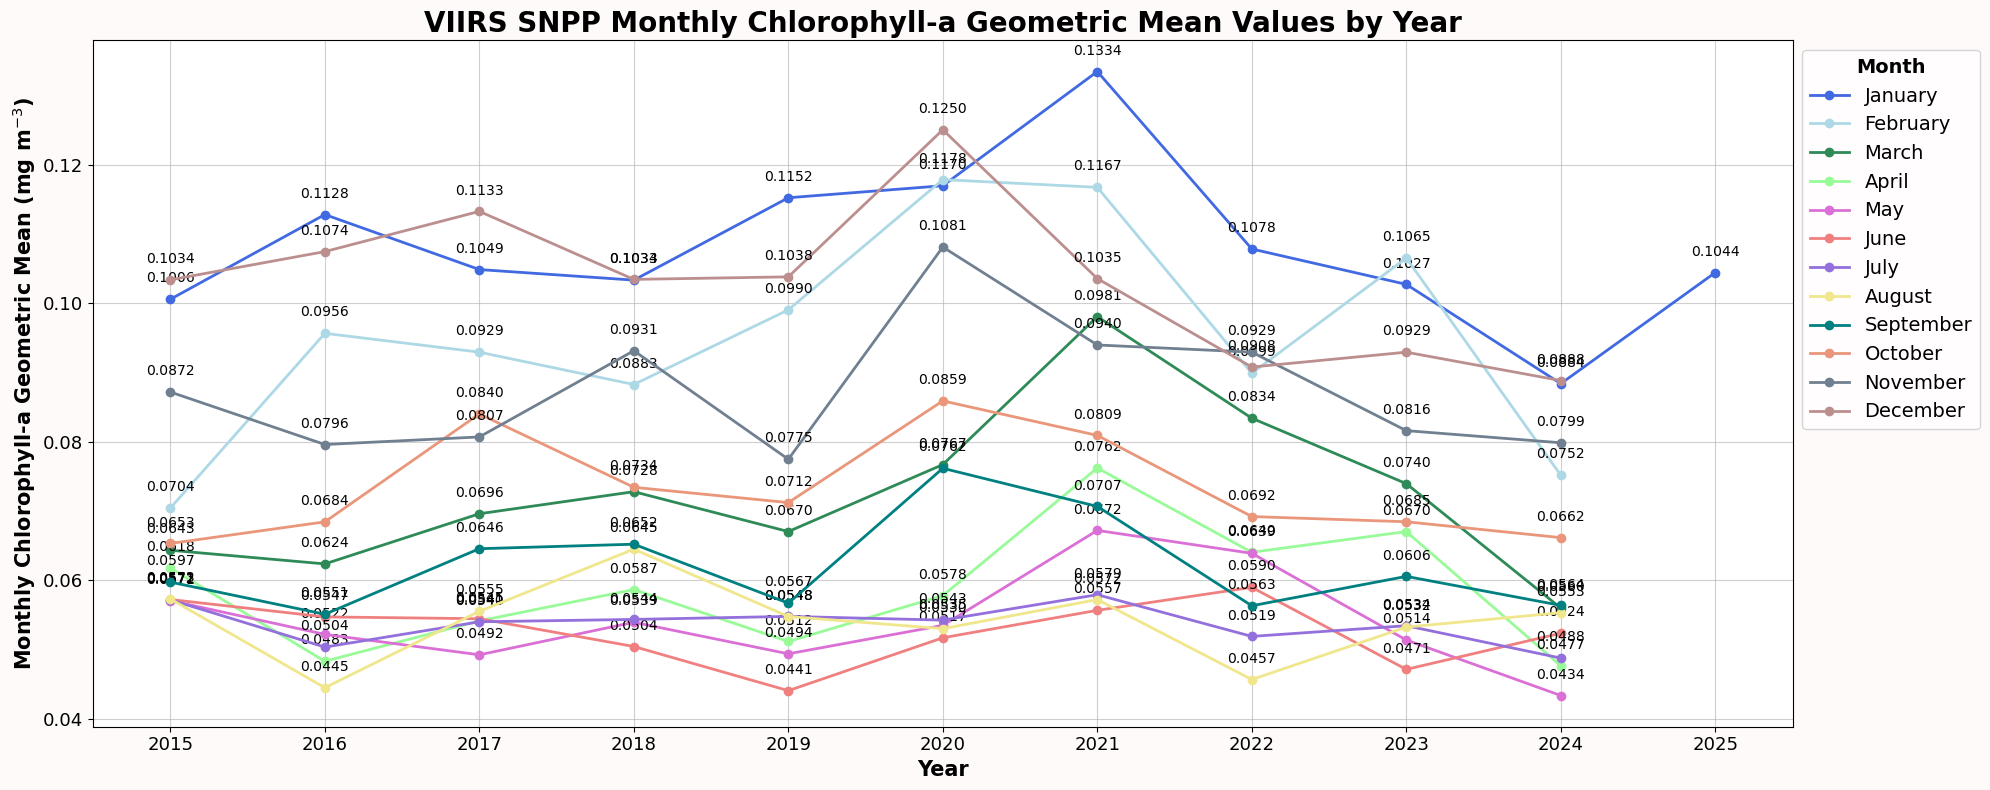

In [13]:
# line plot
fig, ax = plt.subplots(figsize=(20, 8), facecolor='snow')
x_all = dfp.index  # full list of years

colors = {
    'January': 'royalblue',
    'February': 'lightblue',
    'March': 'seagreen',
    'April': 'palegreen',
    'May': 'orchid',
    'June': 'lightcoral',
    'July': 'mediumpurple',
    'August': 'khaki',
    'September': 'teal',
    'October': 'darksalmon',
    'November': 'slategrey',
    'December': 'rosybrown'
}

for month in dfp.columns:
    # Filter out missing or zero values
    month_data = dfp[month]
    valid_mask = month_data > 0  # Or use ~month_data.isna() if you prefer
    x = dfp.index[valid_mask]
    y = month_data[valid_mask]

    if len(x) == 0:
        continue  # skip months with no data at all

    ax.plot(x, y, label=month, color=colors[month], marker='o', linewidth=2, zorder=3)

    # Add point labels
    for xi, yi in zip(x, y):
        ax.text(xi, yi + 0.002, f'{yi:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Monthly Chlorophyll-a Geometric Mean (mg m$^{-3}$)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year', fontsize=15, fontweight='bold')
ax.set_title('VIIRS SNPP Monthly Chlorophyll-a Geometric Mean Values by Year', fontsize=20, fontweight='bold')
legend = ax.legend(title='Month', bbox_to_anchor=(1, 1), loc='upper left', title_fontsize=14, fontsize=14)
legend.get_title().set_fontweight('bold')
plt.xticks(x_all, fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, alpha=0.6, zorder=0)
plt.tight_layout()
plt.savefig('/home/jovyan/Desktop/figures/VIIRS SNPP 8-D/GMean_lineplot_month.png', bbox_inches='tight', dpi=300)

In [14]:
df_avg = df.loc[df['start month'] == 1]
df_avg = df_avg.drop(columns=['end year', 'end day', 'start day', 'end month'])
df_avg = df_avg.groupby(['start year', 'start month']).mean(numeric_only=True)
df_avg.reset_index(inplace=True)
df_avg

,start year,start month,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N
0,2015,1,0.102757,0.100566,0.099245,0.021938,1.229907,0.000481,25418.25
1,2016,1,0.115555,0.112790,0.109998,0.026393,1.244298,0.000698,24505.75
2,2017,1,0.109344,0.104852,0.101257,0.033051,1.322618,0.001138,22873.25
3,2018,1,0.106456,0.103327,0.101362,0.027248,1.268552,0.000763,24182.50
4,2019,1,0.118675,0.115216,0.108059,0.031131,1.264994,0.000976,24971.00
5,2020,1,0.121385,0.116953,0.115836,0.034914,1.310169,0.001241,21427.25
6,2021,1,0.137922,0.133432,0.127034,0.040916,1.274745,0.001694,25369.50
7,2022,1,0.112461,0.107825,0.106570,0.033084,1.329044,0.001150,22786.25
8,2023,1,0.106762,0.102714,0.100584,0.032917,1.308524,0.001087,25664.75
9,2024,1,0.092541,0.088387,0.086225,0.030270,1.349703,0.000928,23085.25


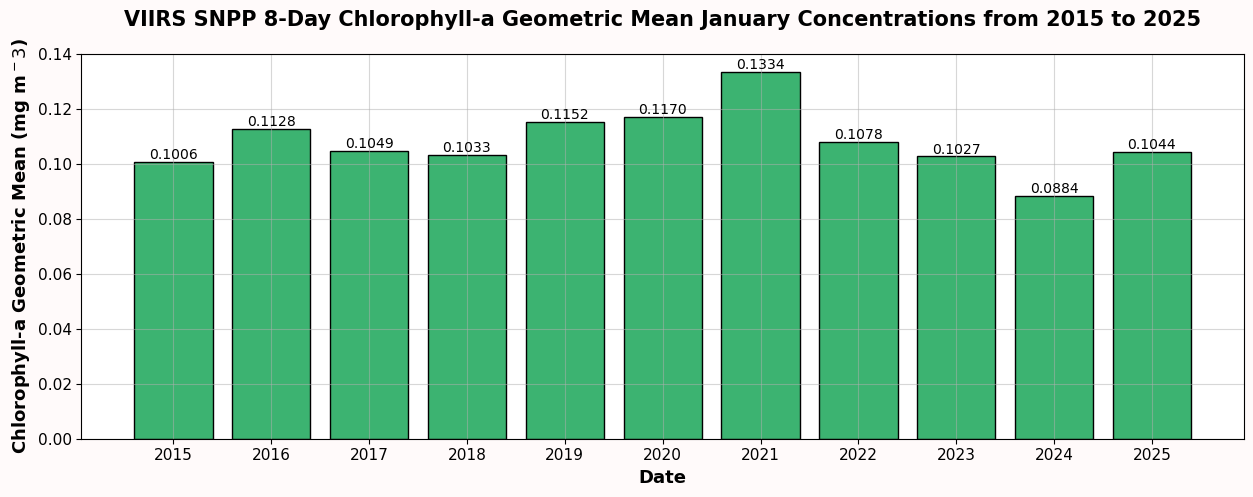

In [15]:
chl_a_avg = df_avg['chl-a geometric mean'].values
start_year = df_avg['start year'].values
variable = 'Geometric Mean'

fig = plt.figure(figsize = (15,5), facecolor = 'snow')
#plt.bar(start_year, chl_a_avg, width = 0.8, color='mediumseagreen')
bars = plt.bar(start_year, chl_a_avg, color='mediumseagreen', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  
        height + 0,                    
        f'{height:.4f}',                  
        ha='center', va='bottom'  # horizontally center, align to bottom
    )
plt.tick_params(axis = 'x', rotation=0, labelsize = 11)
plt.tick_params(axis = 'y', labelsize = 11)
plt.grid(True, alpha = 0.5)
plt.ylabel(f'Chlorophyll-a {variable} (mg m$^{-3}$)', fontsize = 13, fontweight = 'bold') #rotation = 0, labelpad = 130)
plt.xlabel('Date', fontsize = 13, fontweight = 'bold', rotation = 0)
plt.xticks(start_year)
plt.title(f'VIIRS SNPP 8-Day Chlorophyll-a {variable} January Concentrations from 2015 to 2025', fontsize = 15, fontweight = 'bold', pad = 20)
plt.savefig(f'/home/jovyan/Desktop/figures/VIIRS Chl-a Jan {variable} Concentrations', bbox_inches = 'tight', dpi = 300)

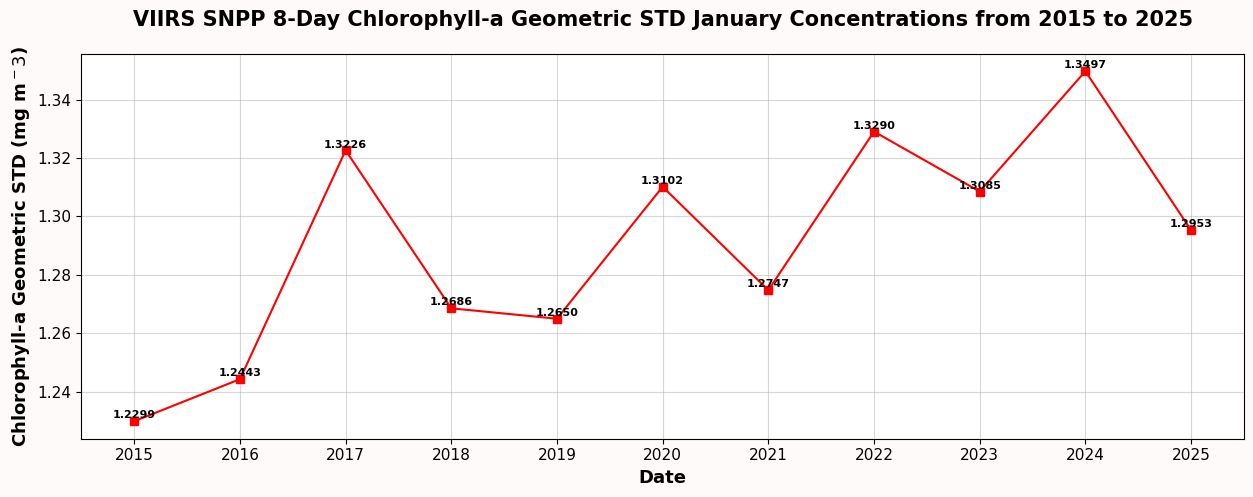

In [39]:
chl_a_avg = df_avg['chl-a geometric mean'].values
start_year = df_avg['start year'].values
variable = 'Geometric Mean'

fig = plt.figure(figsize = (15,5), facecolor = 'snow')
plt.plot(start_year, chl_a_avg,  marker = 's', color='mediumseagreen')
# Add value labels to each point
for x, y in zip(start_year, chl_a_avg):
    plt.text(x, y + 0.0003, f'{y:.4f}', ha='center', va='bottom', fontsize=8, color='black', fontweight = 'bold')  # adjust y + 0.01 as needed

plt.tick_params(axis = 'x', rotation=0, labelsize = 11)
plt.tick_params(axis = 'y', labelsize = 11)
plt.grid(True, alpha = 0.5)
plt.ylabel(f'Chlorophyll-a {variable} (mg m$^{-3}$)', fontsize = 13, fontweight = 'bold') #rotation = 0, labelpad = 130)
plt.xlabel('Date', fontsize = 13, fontweight = 'bold', rotation = 0)
plt.xticks(start_year)
plt.title(f'VIIRS SNPP 8-Day Chlorophyll-a {variable} January Concentrations from 2015 to 2025', fontsize = 15, fontweight = 'bold', pad = 20)
plt.savefig(f'/home/jovyan/Desktop/figures/VIIRS SNPP 8-D/lineplot_VIIRS Chl-a Jan {variable} Concentrations', bbox_inches = 'tight', dpi = 300)

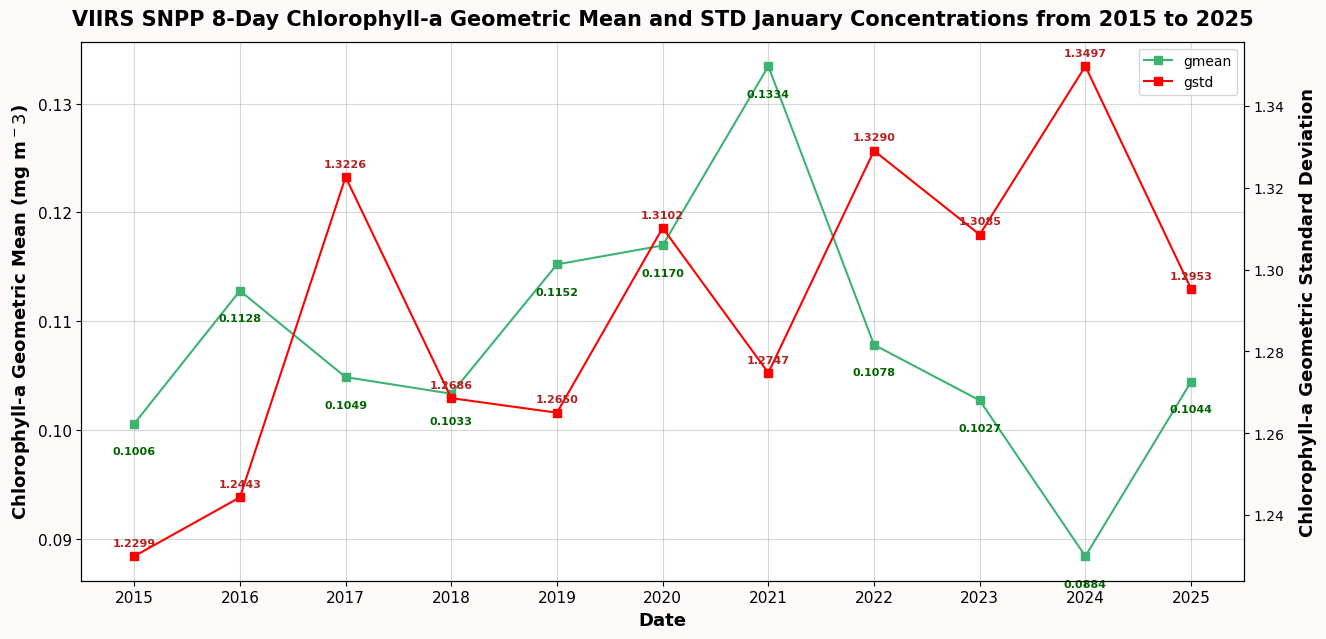

In [115]:
chl_a_avg = df_avg['chl-a geometric mean'].values
start_year = df_avg['start year'].values
variable = 'Geometric Mean'

fig, ax1 = plt.subplots(figsize = (15,7), facecolor = 'snow')
line1, = ax1.plot(start_year, chl_a_avg,  marker = 's', color='mediumseagreen', label = 'gmean')
# Add value labels to each point
for x, y in zip(start_year, chl_a_avg):
    ax1.text(x, y - 0.003, f'{y:.4f}', ha='center', va='bottom', fontsize=8, color='darkgreen', fontweight = 'bold', zorder = 5)  # adjust y + 0.01 as needed

plt.tick_params(axis = 'x', rotation=0, labelsize = 11)
plt.tick_params(axis = 'y', labelsize = 11)
plt.grid(True, alpha = 0.5)
ax1.set_ylabel(f'Chlorophyll-a {variable} (mg m$^{-3}$)', fontsize = 13, fontweight = 'bold') #rotation = 0, labelpad = 130)
plt.xlabel('Date', fontsize = 13, fontweight = 'bold', rotation = 0)
plt.xticks(start_year)
plt.title(f'VIIRS SNPP 8-Day Chlorophyll-a Geometric Mean and STD January Concentrations from 2015 to 2025', fontsize = 15, fontweight = 'bold', pad = 12)

ax2 = ax1.twinx()
chl_a_gstd = df_avg['chl-a geometric std'].values
line2, = ax2.plot(start_year, chl_a_gstd,  marker = 's', color='r', label = 'gstd')
# Add value labels to each point
for x, y in zip(start_year, chl_a_gstd):
    plt.text(x, y + 0.002, f'{y:.4f}', ha='center', va='bottom', fontsize=8, color='firebrick', fontweight = 'bold')  # adjust y + 0.01 as needed
ax2.set_ylabel(f'Chlorophyll-a Geometric Standard Deviation', fontsize = 13, fontweight = 'bold', rotation = 90, labelpad=10) 

# get the legend
lines = [line1,line2] # make a list with the lines and their labels
labels = [line.get_label() for line in lines] # get the labels from the lines
plt.legend(lines, labels, loc = 'upper right')
plt.savefig(f'/home/jovyan/Desktop/figures/VIIRS SNPP 8-D/lineplot_VIIRS gmean gstd Jan Concentrations', bbox_inches = 'tight', dpi = 300)